In [1]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import load_img_natraster


In [2]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'three0'
    date: str =  '250313' 
    brain_area: str = 'AIT'
    new_fs: int = 100 # Hz
    
cfg = Cfg()


In [3]:
raster = load_img_natraster(paths, cfg.monkey_name, cfg.date, new_fs=cfg.new_fs)

In [4]:
raster.get_array().shape

(383, 30, 776)

In [19]:
areas_dict_mm = {'V1': [37, 40], 'V2': [33, 36], 'V3': [29, 32.5], 'CIT': [4.3, 11.3], 'AIT': [0, 3]}
chan_indices = []
for area, mm in areas_dict_mm.items():
    chan_indices.append(np.round(np.array(mm)*382/45).astype(int))

[314 340]
[280 306]
[246 276]
[37 96]
[ 0 25]


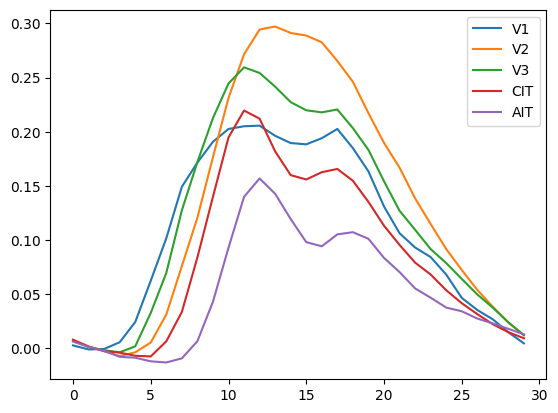

In [22]:
areas_list = ['V1', 'V2', 'V3', 'CIT', 'AIT']
for i, area in zip(chan_indices, areas_list):
    print(i)
    avg_activity = np.mean(raster.get_array()[i[0]:i[1], :, :], axis=(0,2))
    plt.plot(avg_activity, label=area)
plt.legend()